In [20]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

In [31]:
adata = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_celloracle_compatible_v2.h5ad')

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [32]:
adata

AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

In [33]:
adata.obs['C_scANVI'].value_counts()

C_scANVI
Fast IIX         34128
Fast IIB         33378
MTJ               5034
EC                3263
FAPs              2830
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
NMJ               1066
Macrophages        968
Name: count, dtype: int64

### Re-annotate the cell-populations to separate out the type2a population

In [34]:
adata_full = adata.raw.to_adata()
adata_full.obs = adata.obs.copy()
adata_full.obs_names_make_unique()

# Look at the actual non-zero values, not the top-left corner
import numpy as np
from scipy import sparse
X = adata_full.X
nz = X.data[:10000] if sparse.issparse(X) else X[X != 0][:10000]
print("non-zero sample:", nz[:20])
print("min / max / mean:", nz.min(), nz.max(), nz.mean())

is_counts = np.allclose(nz, nz.astype(int))
print(f"raw.X looks like {'counts' if is_counts else 'log-normalized'}")

if is_counts:
    sc.pp.normalize_total(adata_full, target_sum=1e4)
    sc.pp.log1p(adata_full)

non-zero sample: [1.20294712 1.20294712 1.73339425 1.73339425 2.70668238 1.20294712
 1.20294712 2.97753414 2.85125045 2.85125045 1.73339425 1.20294712
 3.08964353 2.07815927 2.70668238 1.20294712 1.20294712 1.20294712
 2.33405125 1.20294712]
min / max / mean: 1.0257651570429829 7.200938873661968 1.6548693688666176
raw.X looks like log-normalized


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [35]:
import pandas as pd

# Pool of cells eligible for fiber-type reassignment
fast_pool = adata.obs["C_scANVI"].isin(["Fast IIX", "Fast IIB", "MTJ"])

# Myosin expression from the full-gene object
expr = sc.get.obs_df(adata_full, ["Myh2", "Myh1", "Myh4", "Myh7"])
expr.index = adata.obs_names

detected = (expr.max(axis=1) > 0.5) & fast_pool
winner = expr.idxmax(axis=1)
label_map = {"Myh2": "IIA", "Myh1": "IIX", "Myh4": "IIB", "Myh7": "I"}

# Start from the original annotation
re_annot = adata.obs["C_scANVI"].astype(str).copy()

# Fast IIX / Fast IIB cells: flatten to their dominant-myosin fiber type
fast_only = detected & adata.obs["C_scANVI"].isin(["Fast IIX", "Fast IIB"])
re_annot.loc[fast_only] = winner[fast_only].map(label_map).map(
    {"IIA": "Fast IIA", "IIX": "Fast IIX", "IIB": "Fast IIB", "I": "Fast I"}
).values

# MTJ cells: keep MTJ identity, append fiber-type subtype
mtj_call = detected & (adata.obs["C_scANVI"] == "MTJ")
re_annot.loc[mtj_call] = ("MTJ-" + winner[mtj_call].map(label_map)).values

adata.obs["re_annot"] = pd.Categorical(re_annot)
print(adata.obs["re_annot"].value_counts())
print(pd.crosstab(adata.obs["C_scANVI"], adata.obs["re_annot"]))

re_annot
Fast IIB         42262
Fast IIX         21819
Fast IIA          3414
EC                3263
FAPs              2830
MTJ-IIB           2736
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
MTJ-IIX           1767
NMJ               1066
Macrophages        968
MTJ-IIA            511
MTJ                 17
Fast I              11
MTJ-I                3
Name: count, dtype: int64
re_annot         EC  FAPs  Fast I  Fast IIA  Fast IIB  Fast IIX  MTJ  MTJ-I  \
C_scANVI                                                                      
EC             3263     0       0         0         0         0    0      0   
FAPs              0  2830       0         0         0         0    0      0   
Fast IIB          0     0       0        26     32845       507    0      0   
Fast IIX          0     0      11      3388      9417     21312    0      0   
MTJ               0     0       0         0         0         0   17      3   
Macrophages       0     0       0         0 

In [36]:
# Drop cells in any re_annot category with fewer than 50 members
min_cells = 50
keep_cats = adata.obs["re_annot"].value_counts()
keep_cats = keep_cats[keep_cats >= min_cells].index.tolist()

adata_re = adata[adata.obs["re_annot"].isin(keep_cats)].copy()
adata_re.obs["re_annot"] = (
    adata_re.obs["re_annot"].cat.remove_unused_categories()
)

print(f"dropped {adata.n_obs - adata_re.n_obs} cells "
      f"from {len(adata.obs['re_annot'].cat.categories) - len(keep_cats)} categories")
print(adata_re.obs["re_annot"].value_counts())

dropped 31 cells from 3 categories
re_annot
Fast IIB         42262
Fast IIX         21819
Fast IIA          3414
EC                3263
FAPs              2830
MTJ-IIB           2736
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
MTJ-IIX           1767
NMJ               1066
Macrophages        968
MTJ-IIA            511
Name: count, dtype: int64


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [53]:
re_annot_palette = {
    "Fast IIA":      "#1B5E20",
    "Fast IIB":      "#4A148C",
    "Fast IIX":      "#FFAB91",
    "MTJ-IIA":       "#A5D6A7",
    "MTJ-IIB":       "#B39DDB",
    "MTJ-IIX":       "#EFE0C5",
    "EC":            "#E53935",
    "FAPs":          "#1E88E5",
    "Pericyte":      "#D2B48C",
    "Tendon":        "#6D4C41",
    "Skeleton MuSc": "#00897B",
    "NMJ":           "#FDD835",
    "Macrophages":   "#F57C00",
}

# C_scANVI shares most names with re_annot, but has the unsplit "MTJ" instead
# of MTJ-IIA/IIB/IIX. Pick an MTJ color that doesn't clash with anything else —
# medium purple sits between the IIA and stromal palettes.
c_scanvi_palette = {**re_annot_palette, "MTJ": "#7E57C2"}

# Make sure both columns are clean Categoricals
for col, pal in [("re_annot", re_annot_palette), ("C_scANVI", c_scanvi_palette)]:
    adata_re.obs[col] = adata_re.obs[col].astype(str).astype("category")
    cats = [c for c in adata_re.obs[col].cat.categories if c in pal]
    # Drop any cells in non-palette categories (shouldn't be any after filtering)
    adata_re = adata_re[adata_re.obs[col].isin(cats)].copy()
    adata_re.obs[col] = adata_re.obs[col].astype(str).astype("category")
    counts = adata_re.obs[col].value_counts().sort_values(ascending=False)
    adata_re.obs[col] = adata_re.obs[col].cat.reorder_categories(counts.index.tolist())
    adata_re.uns[f"{col}_colors"] = [pal[c] for c in adata_re.obs[col].cat.categories]


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


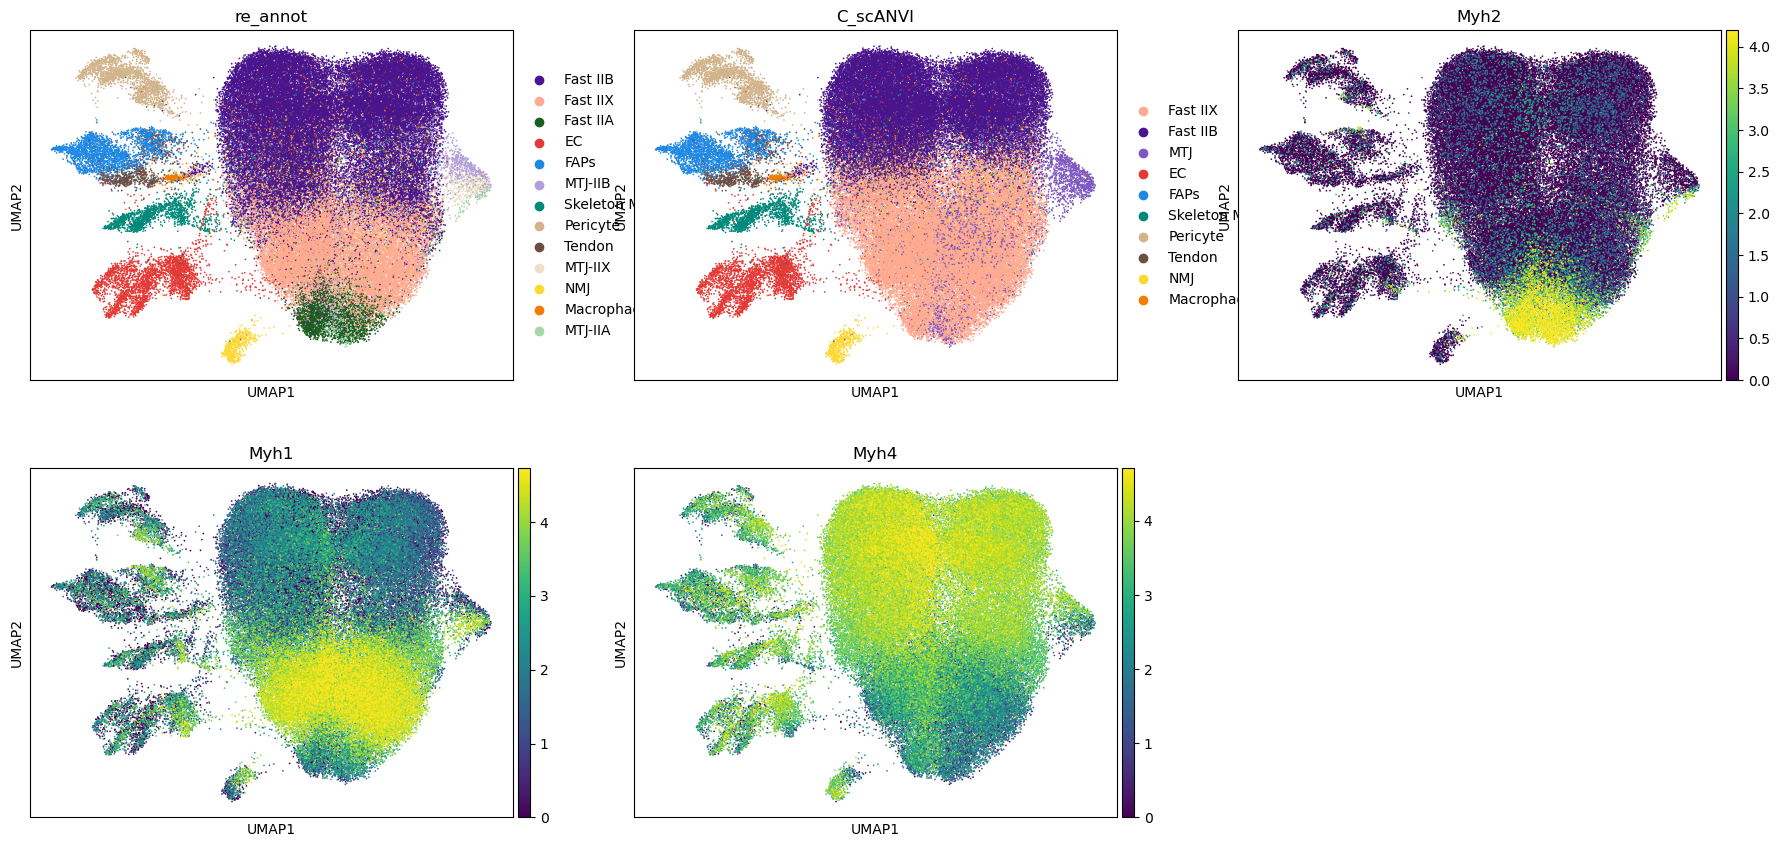

In [54]:
sc.pl.umap(
    adata_re,
    color=["re_annot", "C_scANVI", "Myh2", "Myh1", "Myh4"],
    ncols=3, vmax="p99", size=6,
)

### Inspect the clustering

In [29]:
# Drop Fast I but keep the ORIGINAL UMAP coords (don't recompute).
keep = adata.obs["re_annot"] != "Fast I"
adata_re = adata[keep].copy()
adata_re.obs["re_annot"] = adata_re.obs["re_annot"].cat.remove_unused_categories()

# Order categories so rare types plot last (on top)
counts = adata_re.obs["re_annot"].value_counts().sort_values(ascending=False)
adata_re.obs["re_annot"] = adata_re.obs["re_annot"].cat.reorder_categories(counts.index.tolist())


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


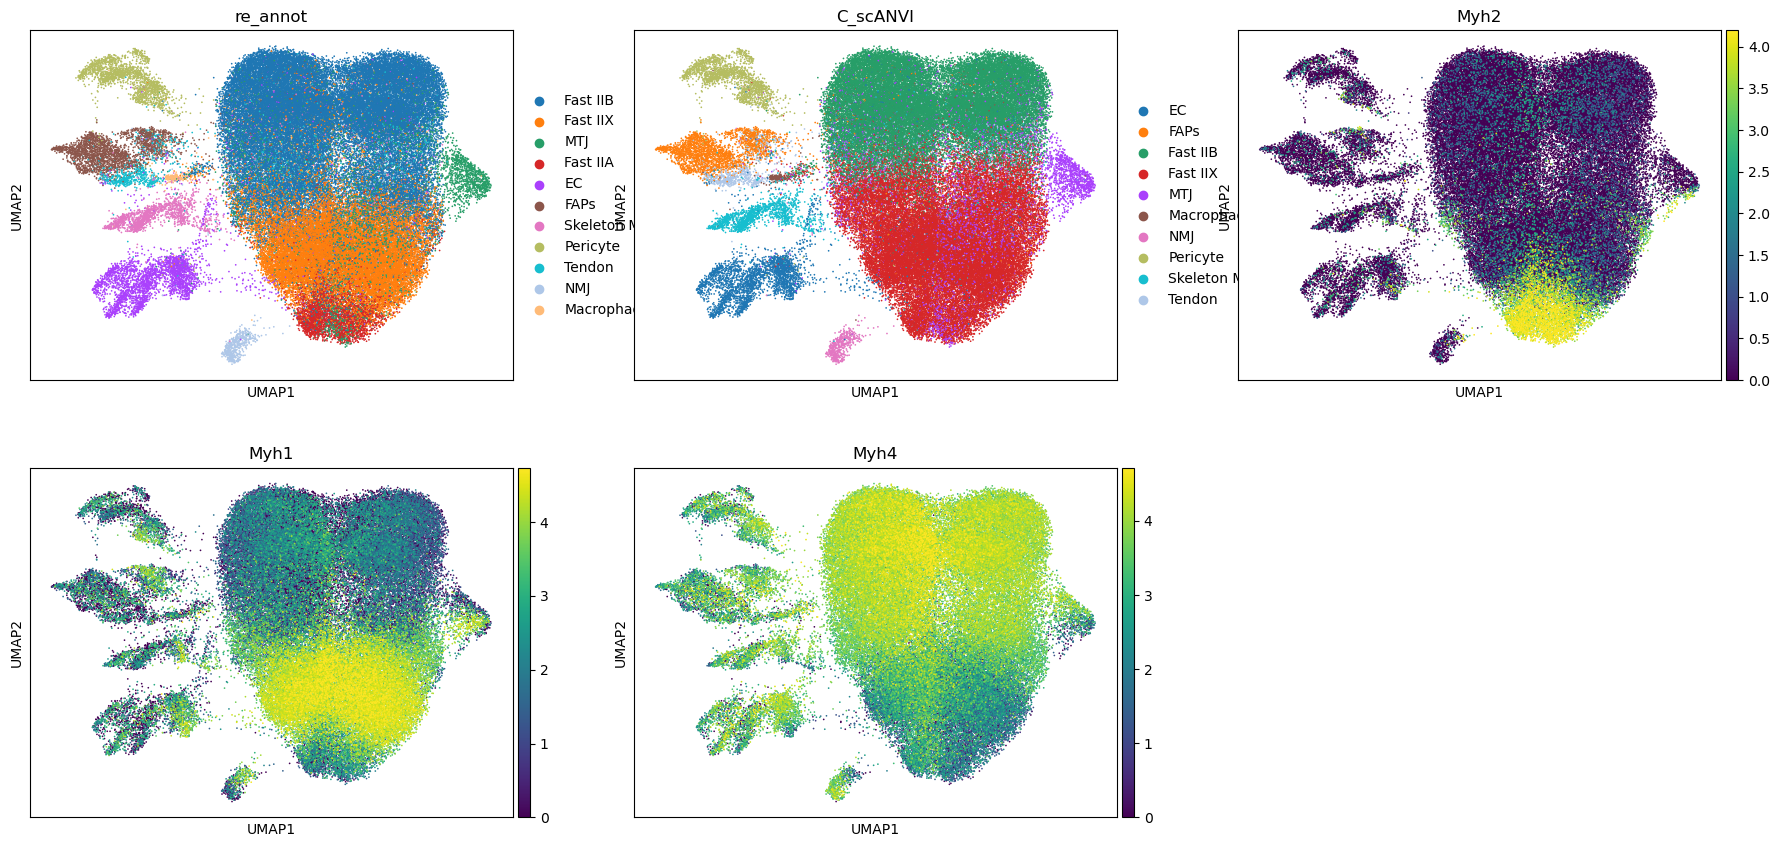

In [30]:
sc.pl.umap(
    adata_re,
    color=["re_annot", "C_scANVI", "Myh2", "Myh1", "Myh4"],
    ncols=3, vmax="p99", size=6,
)

In [ ]:
adata_sex = adata[adata.obs['sex'] == 'F']

In [ ]:
adata_sex.obs

In [ ]:
adata_plot = adata_sex[adata_sex.obs['C_scANVI'].isin(['Fast IIX', 'Fast IIB'])]

In [ ]:
# find var_names containing 'Sod'
adata_plot.var_names[adata_plot.var_names.str.contains('Myh2')] #not highly expressed so got filtered out in pre-processing

In [ ]:
adata_plot.obs

## gene expression related plots

In [ ]:
sc.pl.embedding(adata_sex, basis='umap', color='C_scANVI', show=False)
# plt.savefig(f'{figures_dir}/Male_2x_2b_cell_type.svg',
#               bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
adata_sex.X.min(), adata_plot.X.max()

In [ ]:
sc.pl.embedding(adata_sex, basis='umap',
                  color=['Myh2'],
                  vmin=0, vmax='p99', show=False)
# plt.savefig(f'{figures_dir}/Male_2x_2b_Myh1.svg',
#               bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
sc.pl.embedding(adata_sex, basis='umap',
                  color=['Tnnt2'],show=False)
# plt.savefig(f'{figures_dir}/Male_2x_2b_Tnnt2.svg',
#               bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['Myh1', 'Tnnt2'], groupby='condition', show=False)
plt.savefig(f'{figures_dir}/Female_Myh1_Tnnt2_dotplot.svg',
              bbox_inches='tight', dpi=300)
plt.show()

### Cell proportions
#### 1. Sankey plot for 4 subsets where the width of the flow shows how much of that category's population maps to the different cell types
#### 2. Pie charts to show cell-type population differences between male and female

In [ ]:
#df = adata_whole.obs.groupby(['sex_condition', 'C_scANVI']).size().reset_index(name='count')
df = adata_whole.obs.groupby(['sex', 'C_scANVI']).size().reset_index(name='count')

# rename sex_condition to group
# df = df.rename(columns={'sex_condition': 'group'})
df = df.rename(columns={'sex': 'group'})
# rename C_scANVI to cell_type
df = df.rename(columns={'C_scANVI': 'cell_type'})
display(df.head())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patches as patches
import pandas as pd

# ── CONFIG ──────────────────────────────────────────────────────────────────
LEFT_COL   = 'sex'
RIGHT_COL  = 'C_scANVI'
LEFT_ORDER = ['F', 'M']

COLOR_MAP = {
    'F': '#e8a0a0',
    'M': '#5dbdb2',
}

# scanpy cell type colors — auto-pulled or define manually
cell_type_colors = dict(zip(
    adata_whole.obs[RIGHT_COL].cat.categories,
    adata_whole.uns.get(f'{RIGHT_COL}_colors', 
        plt.cm.tab20.colors[:len(adata_whole.obs[RIGHT_COL].cat.categories)])
))

# ── DATA ────────────────────────────────────────────────────────────────────
df = adata_whole.obs.groupby([LEFT_COL, RIGHT_COL]).size().reset_index(name='count')

left_groups  = LEFT_ORDER
right_groups = adata_whole.obs[RIGHT_COL].cat.categories.tolist()

# Normalize counts within each left group (proportions)
totals = df.groupby(LEFT_COL)['count'].transform('sum')
df['prop'] = df['count'] / totals

# ── LAYOUT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

BAR_W  = 0.03
GAP    = 0.008
X_LEFT = 0.28   # wider left margin for labels
X_RIGHT= 0.58   # closer to left bar
ALPHA  = 0.4

def calc_positions(groups, counts_dict, x_pos, bar_w):
    """Return {group: (y_bottom, y_top)} for stacked bars."""
    total = sum(counts_dict[g] for g in groups)
    positions = {}
    y = 0.05
    for g in groups:
        h = (counts_dict[g] / total) * 0.9
        positions[g] = (y, y + h)
        y += h + GAP * 0.5
    return positions

# Totals for sizing
left_totals  = df.groupby(LEFT_COL)['count'].sum().to_dict()
right_totals = df.groupby(RIGHT_COL)['count'].sum().to_dict()

left_pos  = calc_positions(left_groups,  left_totals,  X_LEFT,  BAR_W)
right_pos = calc_positions(right_groups, right_totals, X_RIGHT, BAR_W)

# ── DRAW FLOWS ──────────────────────────────────────────────────────────────
# Track current fill position for each bar
left_fill  = {g: left_pos[g][0]  for g in left_groups}
right_fill = {g: right_pos[g][0] for g in right_groups}

left_total_sum = sum(left_totals.values())

for _, row in df.sort_values([LEFT_COL, RIGHT_COL]).iterrows():
    lg, rg, cnt = row[LEFT_COL], row[RIGHT_COL], row['count']

    l_total = left_totals[lg]
    r_total = right_totals[rg]
    l_span  = (left_pos[lg][1] - left_pos[lg][0])
    r_span  = (right_pos[rg][1] - right_pos[rg][0])

    lh = (cnt / l_total) * l_span
    rh = (cnt / r_total) * r_span

    ly0 = left_fill[lg]
    ry0 = right_fill[rg]
    ly1 = ly0 + lh
    ry1 = ry0 + rh

    left_fill[lg]  += lh
    right_fill[rg] += rh

    # Bezier curve path
    verts = [
        (X_LEFT + BAR_W, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry0),
        (X_RIGHT, ry0),
        (X_RIGHT, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly1),
        (X_LEFT + BAR_W, ly1),
        (X_LEFT + BAR_W, ly0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    path  = Path(verts, codes)
    patch = patches.PathPatch(
        path,
        facecolor=COLOR_MAP[lg],
        edgecolor='none',
        alpha=ALPHA,
        zorder=1
    )
    ax.add_patch(patch)

# ── DRAW BARS ────────────────────────────────────────────────────────────────
for g in left_groups:
    y0, y1 = left_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_LEFT, y0), BAR_W, y1 - y0,
        color=COLOR_MAP[g], zorder=2, linewidth=0
    ))
    ax.text(X_LEFT - 0.01, (y0 + y1) / 2, g,
            ha='right', va='center', fontsize=10, fontweight='bold')

for g in right_groups:
    y0, y1 = right_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_RIGHT, y0), BAR_W, y1 - y0,
        color=cell_type_colors.get(g, '#aaaaaa'), zorder=2, linewidth=0
    ))
    ax.text(X_RIGHT + BAR_W + 0.01, (y0 + y1) / 2, g,
            ha='left', va='center', fontsize=9)

plt.title('Cell Proportion', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/figures/sankey_M_F_to_cell_type.pdf', bbox_inches='tight', dpi=300)
# plt.savefig('sankey_moscot_style.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Set the figures directory first
sc.settings.figdir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/figures'

# Then save= is just the filename suffix
sc.pl.umap(adata_whole, color=['C_scANVI'], show=False, save='_C_scANVI.pdf')